--- 1. RÉGRESSION LINÉAIRE SIMPLE ---
Biais (theta0): -302.27
Coefficient Surface (theta1): 7.30

--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---
Biais: -247.42
Coefficients (Surface, Chambres): [ 4.85674931 54.84848485]

--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---
Coefficients (Biais, X, X^2): [ 3.20804196e+02 -6.54615385e+00  6.92307692e-02]



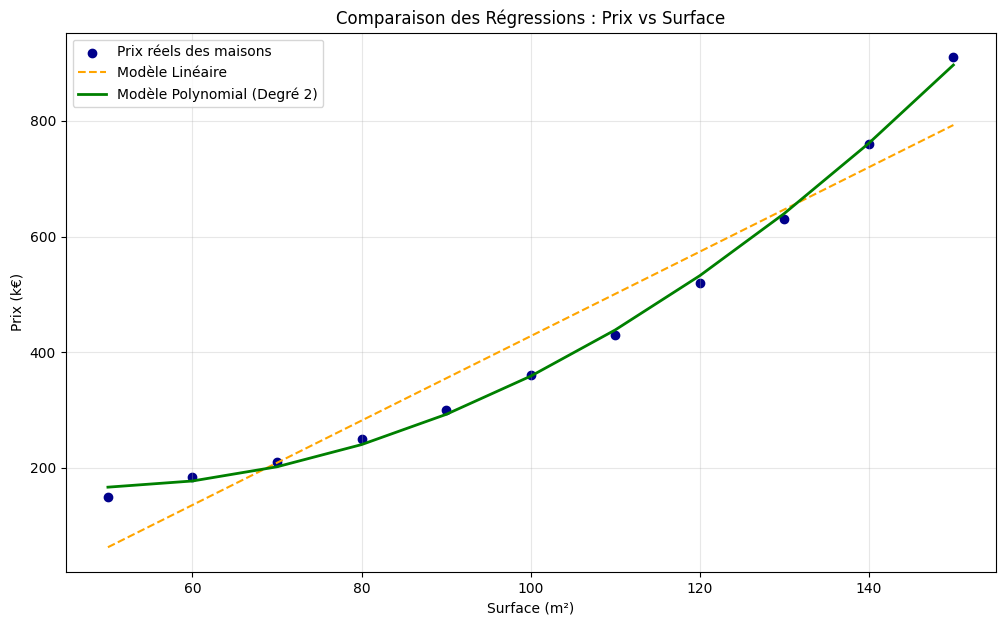

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PRÉPARATION DES DONNÉES (Exemple : Prix de l'immobilier)
# =================================================================
# X_simple : Surface de la maison (en m²)
X_simple = np.array([50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150])

# X_multiple : Surface (Col 1) et Nombre de chambres (Col 2)
X_multiple = np.array([
    [50, 1], [60, 2], [70, 2], [80, 3], [90, 3],
    [100, 3], [110, 4], [120, 4], [130, 5], [140, 5], [150, 6]
])

# y : Prix de la maison (en milliers d'euros)
# On ajoute une légère courbure pour justifier la régression polynomiale plus tard
y = np.array([150, 185, 210, 250, 300, 360, 430, 520, 630, 760, 910])

# =================================================================
# FONCTION CŒUR : L'ÉQUATION NORMALE (Moteur du "From Scratch")
# Cette fonction résout analytiquement le problème de minimisation des moindres carrés.
# Formule mathématique : Theta = (X^T * X)^-1 * X^T * y
# =================================================================
def fit_scratch(X_input, y_target):
    # ÉTAPE 1 : Ajout du biais (Intercept).
    # On ajoute une colonne de 1 pour représenter l'ordonnée à l'origine (theta0).
    X_b = np.c_[np.ones((len(X_input), 1)), X_input]

    # ÉTAPE 2 : Calcul des paramètres optimaux (Theta) via l'algèbre matricielle
    # .T : Transposée, .dot : Produit matriciel, np.linalg.inv : Inversion
    theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_target)

    return theta_best

# =================================================================
# 2. RÉGRESSION LINÉAIRE SIMPLE (Modèle : y = theta0 + theta1*x)
# =================================================================
print("--- 1. RÉGRESSION LINÉAIRE SIMPLE ---")
theta_simple = fit_scratch(X_simple.reshape(-1, 1), y)
print(f"Biais (theta0): {theta_simple[0]:.2f}")
print(f"Coefficient Surface (theta1): {theta_simple[1]:.2f}\n")

# =================================================================
# 3. RÉGRESSION LINÉAIRE MULTIPLE (Modèle : y = theta0 + theta1*x1 + theta2*x2)
# =================================================================
print("--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---")
theta_mult = fit_scratch(X_multiple, y)
print(f"Biais: {theta_mult[0]:.2f}")
print(f"Coefficients (Surface, Chambres): {theta_mult[1:]}\n")

# =================================================================
# 4. RÉGRESSION POLYNOMIALE (Modèle : y = theta0 + theta1*x + theta2*x²)
# =================================================================
print("--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---")
# On crée manuellement la feature X² pour capturer la relation non-linéaire
X_poly_manual = np.c_[X_simple, X_simple**2]
theta_poly = fit_scratch(X_poly_manual, y)
print(f"Coefficients (Biais, X, X^2): {theta_poly}\n")

# =================================================================
# 5. VISUALISATION DES RÉSULTATS
# =================================================================
plt.figure(figsize=(12, 7))
plt.scatter(X_simple, y, color='darkblue', label='Prix réels des maisons')

# Prédiction Linéaire
y_pred_simple = theta_simple[0] + theta_simple[1]*X_simple
plt.plot(X_simple, y_pred_simple, color='orange', linestyle='--', label='Modèle Linéaire')

# Prédiction Polynomiale
y_pred_poly = theta_poly[0] + theta_poly[1]*X_simple + theta_poly[2]*(X_simple**2)
plt.plot(X_simple, y_pred_poly, color='green', linewidth=2, label='Modèle Polynomial (Degré 2)')

plt.title('Comparaison des Régressions : Prix vs Surface')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (k€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- 1. RÉGRESSION LINÉAIRE SIMPLE ---
Biais (Intercept): -302.27
Coefficient Surface: 7.30

--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---
Biais: -247.42
Coefficients (Surface, Chambres): [ 4.85674931 54.84848485]

--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---
Biais: 320.80
Coefficients (X, X^2): [-6.54615385  0.06923077]



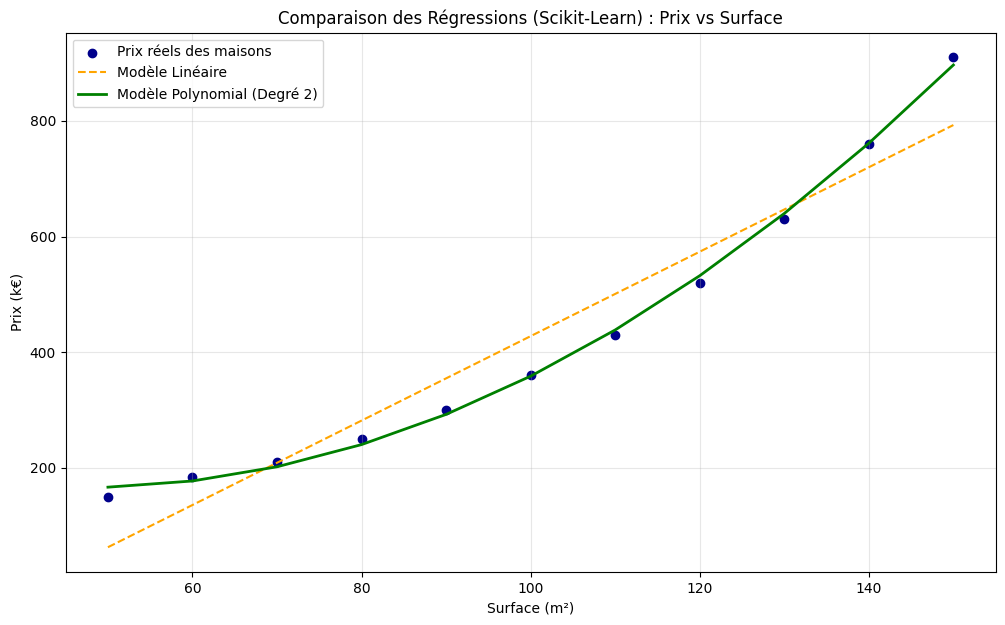

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# =================================================================
# 1. PRÉPARATION DES DONNÉES (Exemple : Prix de l'immobilier)
# =================================================================
# X_simple : Surface de la maison (en m²)
X_simple = np.array([50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]).reshape(-1, 1)

# X_multiple : Surface (Col 1) et Nombre de chambres (Col 2)
X_multiple = np.array([
    [50, 1], [60, 2], [70, 2], [80, 3], [90, 3],
    [100, 3], [110, 4], [120, 4], [130, 5], [140, 5], [150, 6]
])

# y : Prix de la maison (en milliers d'euros)
y = np.array([150, 185, 210, 250, 300, 360, 430, 520, 630, 760, 910])

# =================================================================
# 2. RÉGRESSION LINÉAIRE SIMPLE (Scikit-Learn)
# =================================================================
print("--- 1. RÉGRESSION LINÉAIRE SIMPLE ---")
lin_reg = LinearRegression()
lin_reg.fit(X_simple, y)
print(f"Biais (Intercept): {lin_reg.intercept_:.2f}")
print(f"Coefficient Surface: {lin_reg.coef_[0]:.2f}\n")

# =================================================================
# 3. RÉGRESSION LINÉAIRE MULTIPLE (Scikit-Learn)
# =================================================================
print("--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---")
mult_reg = LinearRegression()
mult_reg.fit(X_multiple, y)
print(f"Biais: {mult_reg.intercept_:.2f}")
print(f"Coefficients (Surface, Chambres): {mult_reg.coef_}\n")

# =================================================================
# 4. RÉGRESSION POLYNOMIALE (Scikit-Learn)
# =================================================================
print("--- 3. RÉGRESSION POLYNOMIALE (Degré 2) ---")
# Étape A : Transformation des features en termes polynomiaux (X, X²)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X_simple)

# Étape B : Application de la régression linéaire sur les nouvelles features
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
print(f"Biais: {poly_reg.intercept_:.2f}")
print(f"Coefficients (X, X^2): {poly_reg.coef_}\n")

# =================================================================
# 5. VISUALISATION DES RÉSULTATS
# =================================================================
plt.figure(figsize=(12, 7))
plt.scatter(X_simple, y, color='darkblue', label='Prix réels des maisons')

# Prédiction Linéaire
y_pred_simple = lin_reg.predict(X_simple)
plt.plot(X_simple, y_pred_simple, color='orange', linestyle='--', label='Modèle Linéaire')

# Prédiction Polynomiale
y_pred_poly = poly_reg.predict(X_poly)
plt.plot(X_simple, y_pred_poly, color='green', linewidth=2, label='Modèle Polynomial (Degré 2)')

plt.title('Comparaison des Régressions (Scikit-Learn) : Prix vs Surface')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (k€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()